In [1]:
#Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Importing harmless warnings
import warnings
warnings.filterwarnings('ignore')

#Notebook Formatting
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
#Importing Dataset
data = pd.read_csv('Breast_cancer_dataset.csv')

In [3]:
#Data Sample
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
#Data Shape
data.shape

(569, 33)

In [5]:
# Data validation and data cleaning


#Dataframe for missing value & datatype
msg_data = pd.DataFrame({'Missing Value' : round(data.isnull().mean()*100), 'Data Type' : data.dtypes})

#Dataframe for 2 sample values
sample = data.head(2).T

#Concating
sample = pd.concat([msg_data, sample], axis = 1)

#Renaming columns
sample.rename(columns = {0: 'Sample_1', 1: 'Sample_2'}, inplace = True)

#Sample DataFrame with missing value columns
sample

,Missing Value,Data Type,Sample_1,Sample_2
id,0.0,int64,842302,842517
diagnosis,0.0,object,M,M
radius_mean,0.0,float64,17.99,20.57
texture_mean,0.0,float64,10.38,17.77
perimeter_mean,0.0,float64,122.8,132.9
area_mean,0.0,float64,1001.0,1326.0
smoothness_mean,0.0,float64,0.1184,0.08474
compactness_mean,0.0,float64,0.2776,0.07864
concavity_mean,0.0,float64,0.3001,0.0869
concave points_mean,0.0,float64,0.1471,0.07017


In [6]:
# Droppping Missing Value
data = data.drop('Unnamed: 32', axis = 1)

In [7]:
# Checking Row Duplicates
row_duplicates = data[data.duplicated(keep=False)]
len(row_duplicates)

0

In [8]:
# Checking Column Duplicates
has_duplicates = data.shape[1] != data.T.drop_duplicates().T.shape[1]

if has_duplicates:
    print('Data has duplicates')
else:
    print('Data has no duplicates')  

Data has no duplicates


In [9]:
# Checking Cat and Num Columns
cat_list = []
num_list = []
cat_list = [cols for cols in data if data[cols].dtypes == 'O']
num_list = [cols for cols in data if data[cols].dtypes != 'O']
print(f'Categorical Cols: {cat_list}')
print(f'\nNumerical Cols: {num_list}')

Categorical Cols: ['diagnosis']

Numerical Cols: ['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [10]:
#No of num and cat cols
print(f'The data has {len(num_list)} numericals columns and {len(cat_list)} categorical columns')

The data has 31 numericals columns and 1 categorical columns


In [11]:
#Checking cols with single unique value
single_unique_cols = []

for col in data.columns:
    if data[col].nunique() == 1:
        single_unique_cols.append(col)

if single_unique_cols:
    print(f'Cols with single unique values: {single_unique_cols}')
else:
    print('Cols with single unique values: 0')

Cols with single unique values: 0


In [12]:
#Checking unique values in ID column
data['id'].nunique()

569

In [13]:
#Dropping ID column
data.drop('id', axis = 1, inplace = True)

## Target column analysis

In [14]:
# Analysing Target Column: Diagnosis
data['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

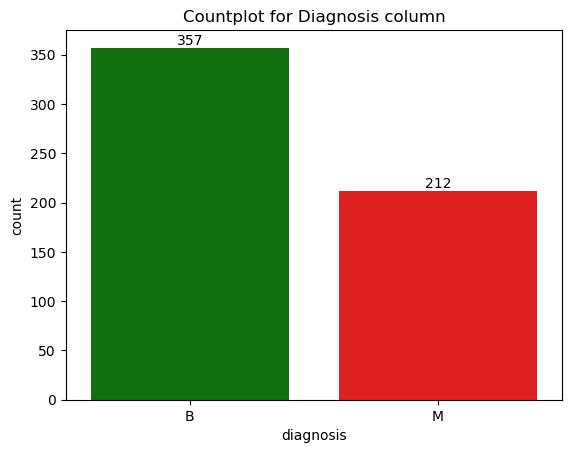

In [15]:
#Plotting the countplot for Diagnosis column

ax = sns.countplot(data, x = 'diagnosis', order = data['diagnosis'].value_counts().index, palette = {'green', 'red'})
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title('Countplot for Diagnosis column')
plt.show()

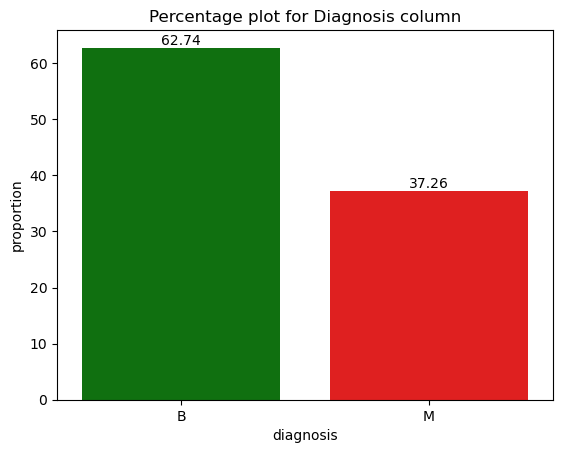

In [16]:
#Plotting the percentage plot for Diagnosis column

ax = sns.barplot(round(data['diagnosis'].value_counts(normalize=True)*100,2), palette = {'green', 'red'})
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title('Percentage plot for Diagnosis column')
plt.show()

# Observation 1

## Univariate Analysis

### Numerical columns

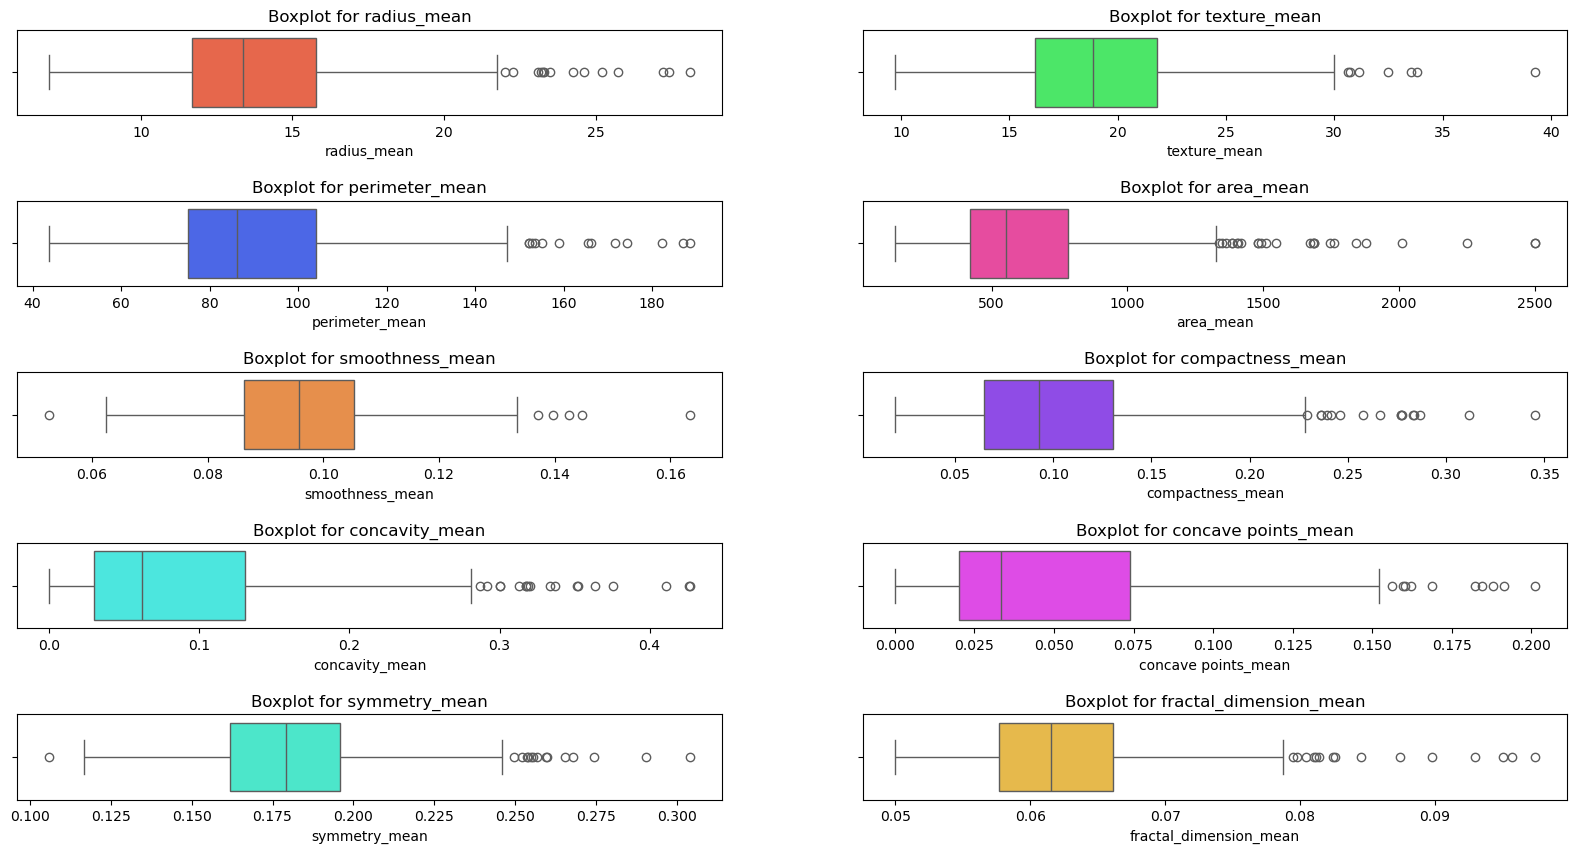

In [17]:
# Boxplot for Mean Columns

fig, axes = plt.subplots(5,2, figsize=(20,10))
plt.subplots_adjust(hspace=1)
axes = axes.flatten()

features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave points_mean",
    "symmetry_mean",
    "fractal_dimension_mean"
]

colors = [
    "#FF5733",  # red
    "#33FF57",  # green
    "#3357FF",  # blue
    "#FF33A1",  # pink
    "#FF8C33",  # orange
    "#8C33FF",  # purple
    "#33FFF5",  # turquoise
    "#F533FF",  # magenta
    "#33FFDB",  # cyan
    "#FFC433"   # yellow
]


for ax, feature, color in zip(axes, features, colors):
    sns.boxplot(data[feature], color=color, ax=ax, orient = 'h')
    ax.set_title(f'Boxplot for {feature}')
plt.show()

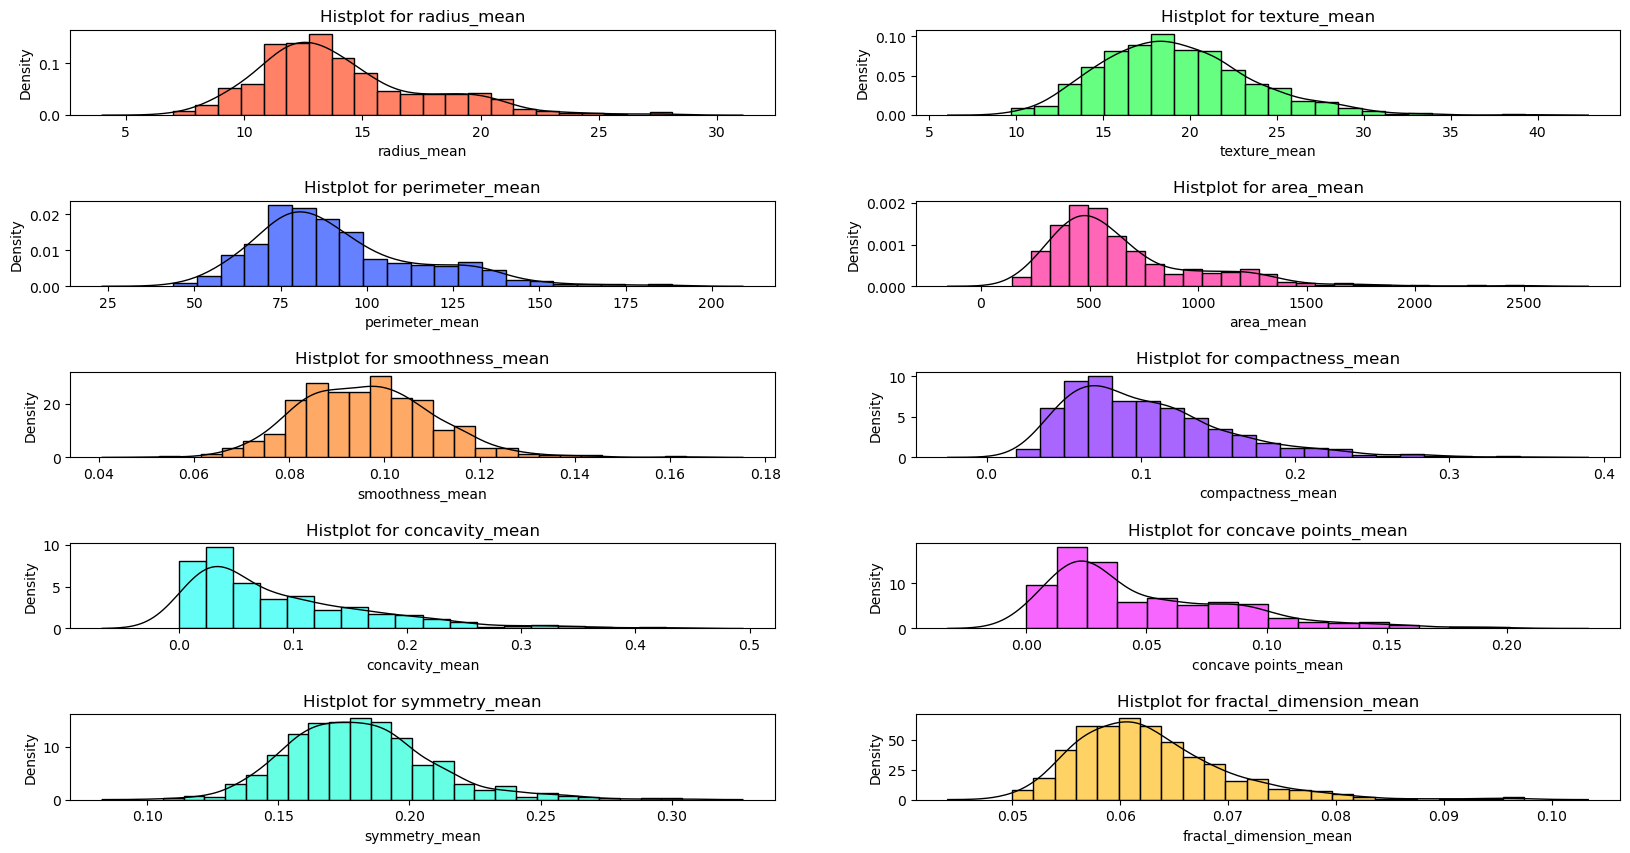

In [18]:
# Histplot for Mean Columns

fig, axes = plt.subplots(5,2, figsize=(20,10))
plt.subplots_adjust(hspace=1)
axes = axes.flatten()

features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave points_mean",
    "symmetry_mean",
    "fractal_dimension_mean"
]

colors = [
    "#FF5733",  # red
    "#33FF57",  # green
    "#3357FF",  # blue
    "#FF33A1",  # pink
    "#FF8C33",  # orange
    "#8C33FF",  # purple
    "#33FFF5",  # turquoise
    "#F533FF",  # magenta
    "#33FFDB",  # cyan
    "#FFC433"   # yellow
]


for ax, feature, color in zip(axes, features, colors):
    
    #Histogram (normalized to density so KDE matches)
    sns.histplot(data[feature], stat="density", color=color, ax=ax, fill=True)
    
    # KDE curve (black line)
    sns.kdeplot(data[feature], color="black", ax=ax, linewidth=1)
    
    ax.set_title(f'Histplot for {feature}')
plt.show()

# Observation 2

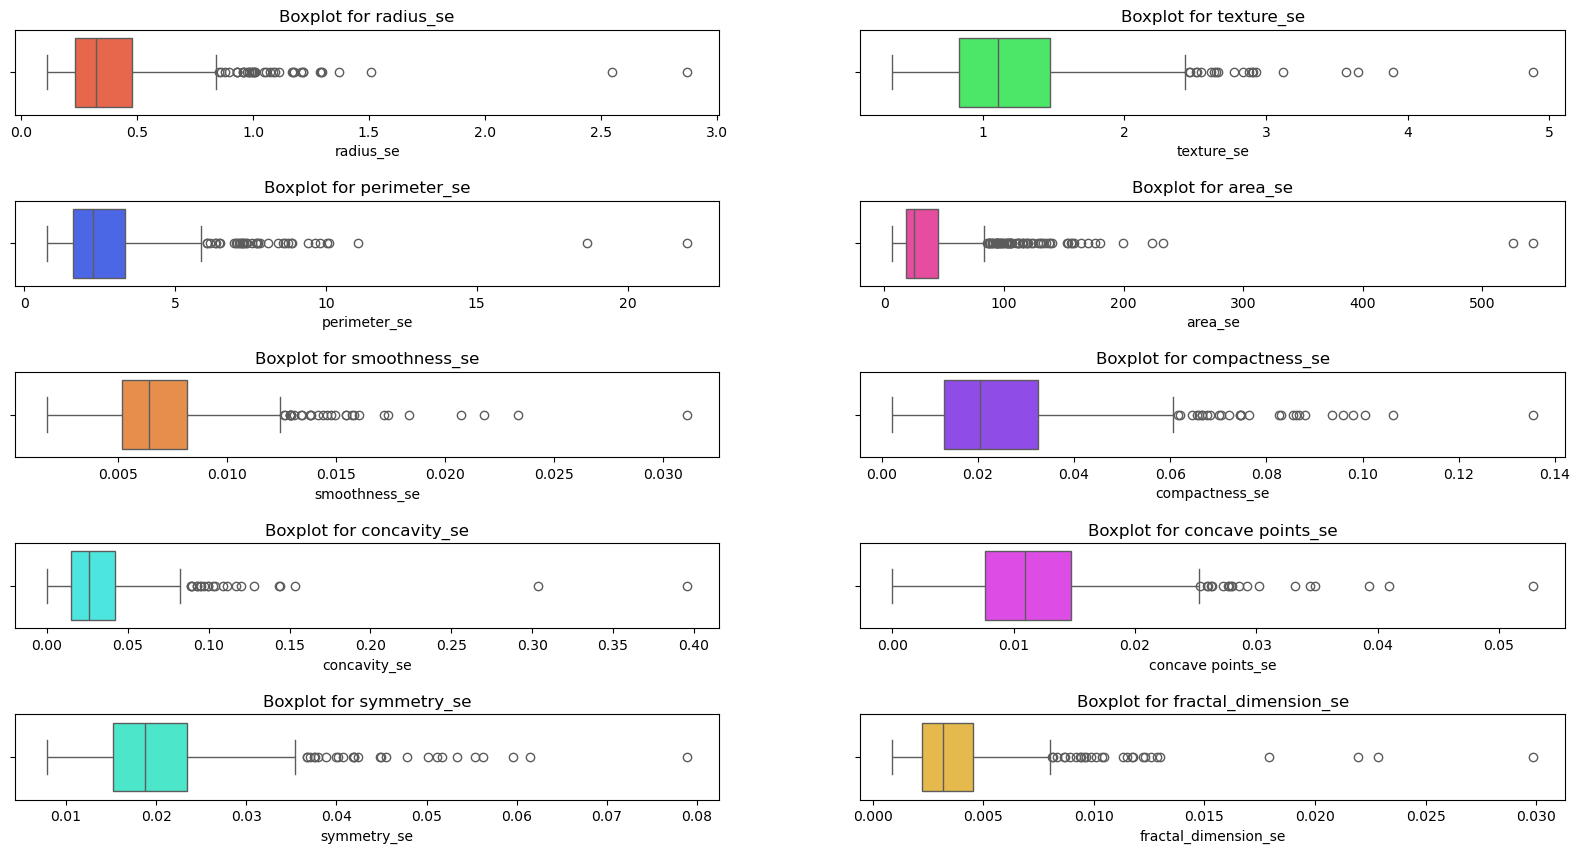

In [19]:
# Boxplot for SE Columns

fig, axes = plt.subplots(5,2, figsize=(20,10))
plt.subplots_adjust(hspace=1)
axes = axes.flatten()

features = [
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave points_se",
    "symmetry_se",
    "fractal_dimension_se"
]

colors = [
    "#FF5733",  # red
    "#33FF57",  # green
    "#3357FF",  # blue
    "#FF33A1",  # pink
    "#FF8C33",  # orange
    "#8C33FF",  # purple
    "#33FFF5",  # turquoise
    "#F533FF",  # magenta
    "#33FFDB",  # cyan
    "#FFC433"   # yellow
]


for ax, feature, color in zip(axes, features, colors):
    sns.boxplot(data[feature], color=color, ax=ax, orient = 'h')
    ax.set_title(f'Boxplot for {feature}')
plt.show()

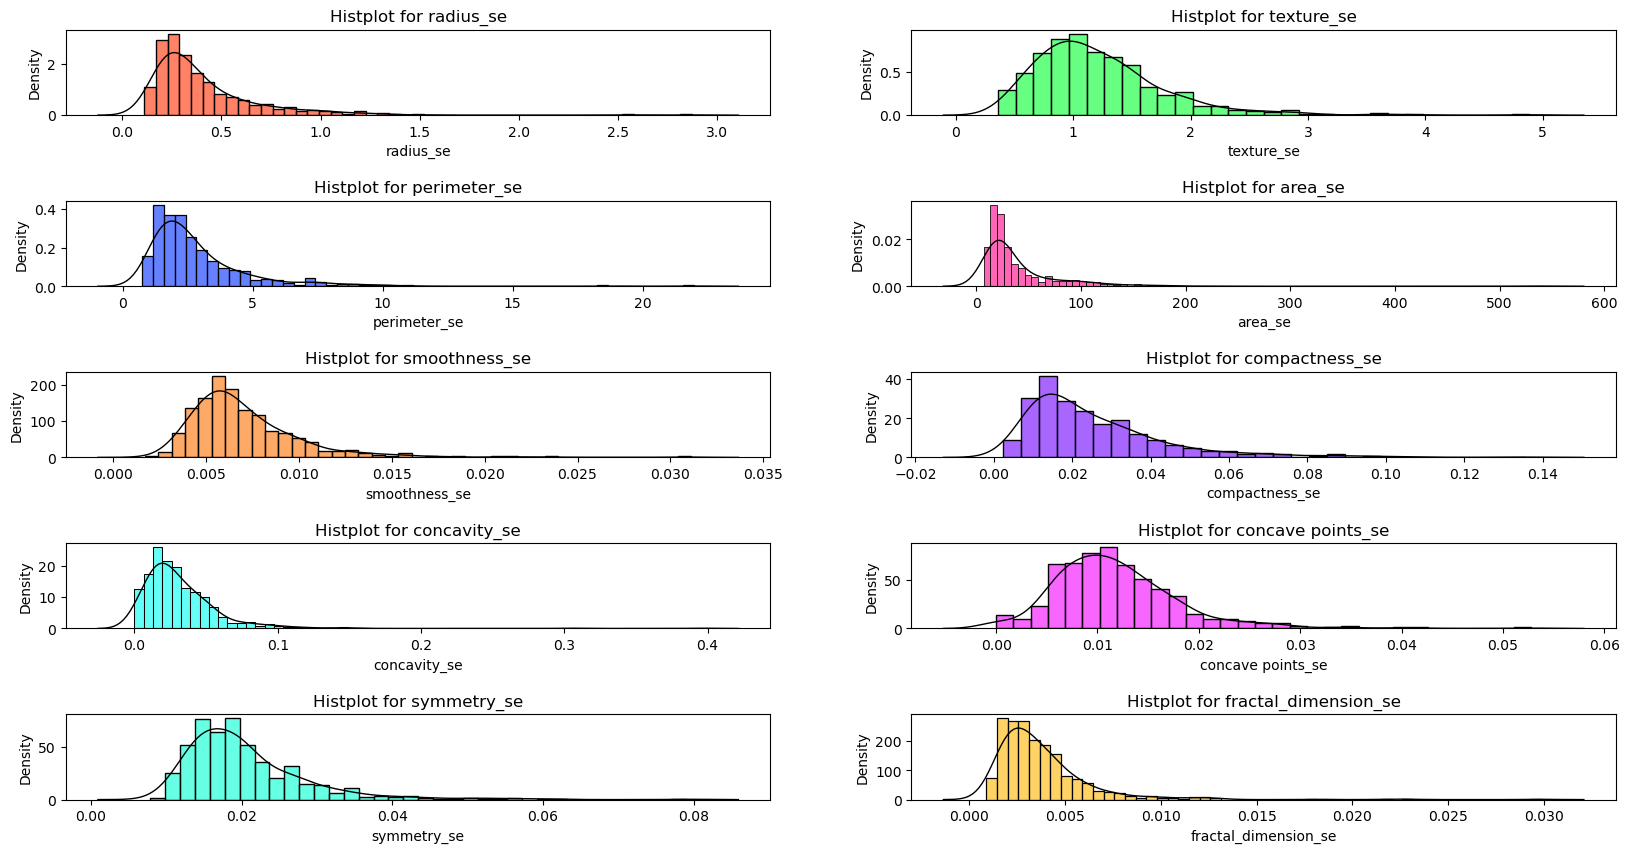

In [20]:
# Histplot for SE Columns

fig, axes = plt.subplots(5,2, figsize=(20,10))
plt.subplots_adjust(hspace=1)
axes = axes.flatten()

features = [
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave points_se",
    "symmetry_se",
    "fractal_dimension_se"
]


colors = [
    "#FF5733",  # red
    "#33FF57",  # green
    "#3357FF",  # blue
    "#FF33A1",  # pink
    "#FF8C33",  # orange
    "#8C33FF",  # purple
    "#33FFF5",  # turquoise
    "#F533FF",  # magenta
    "#33FFDB",  # cyan
    "#FFC433"   # yellow
]


for ax, feature, color in zip(axes, features, colors):
    
    #Histogram (normalized to density so KDE matches)
    sns.histplot(data[feature], stat="density", color=color, ax=ax, fill=True)
    
    # KDE curve (black line)
    sns.kdeplot(data[feature], color="black", ax=ax, linewidth=1)
    
    ax.set_title(f'Histplot for {feature}')
plt.show()

# Observation 3

In [ ]:
# Boxplot for Worst Columns

fig, axes = plt.subplots(5,2, figsize=(20,10))
plt.subplots_adjust(hspace=1)
axes = axes.flatten()

features = [
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

colors = [
    "#FF5733",  # red
    "#33FF57",  # green
    "#3357FF",  # blue
    "#FF33A1",  # pink
    "#FF8C33",  # orange
    "#8C33FF",  # purple
    "#33FFF5",  # turquoise
    "#F533FF",  # magenta
    "#33FFDB",  # cyan
    "#FFC433"   # yellow
]


for ax, feature, color in zip(axes, features, colors):
    sns.boxplot(data[feature], color=color, ax=ax, orient = 'h')
    ax.set_title(f'Boxplot for {feature}')
plt.show()

In [ ]:
# Histplot for Worst Columns

fig, axes = plt.subplots(5,2, figsize=(20,10))
plt.subplots_adjust(hspace=1)
axes = axes.flatten()

features = [
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]


colors = [
    "#FF5733",  # red
    "#33FF57",  # green
    "#3357FF",  # blue
    "#FF33A1",  # pink
    "#FF8C33",  # orange
    "#8C33FF",  # purple
    "#33FFF5",  # turquoise
    "#F533FF",  # magenta
    "#33FFDB",  # cyan
    "#FFC433"   # yellow
]


for ax, feature, color in zip(axes, features, colors):
    
    #Histogram (normalized to density so KDE matches)
    sns.histplot(data[feature], stat="density", color=color, ax=ax, fill=True)
    
    # KDE curve (black line)
    sns.kdeplot(data[feature], color="black", ax=ax, linewidth=1)
    
    ax.set_title(f'Histplot for {feature}')
plt.show()

# Observation 4

In [ ]:
1. All worst columns have strong outliers on the upper fence and have heavy right skewed tails.
2. smoothness_worst column has outlier(s) on the lowerf fence as well.
3. concave points_worst has no outliers

## Bivariate Analysis

### Num v/s Cat(Target)

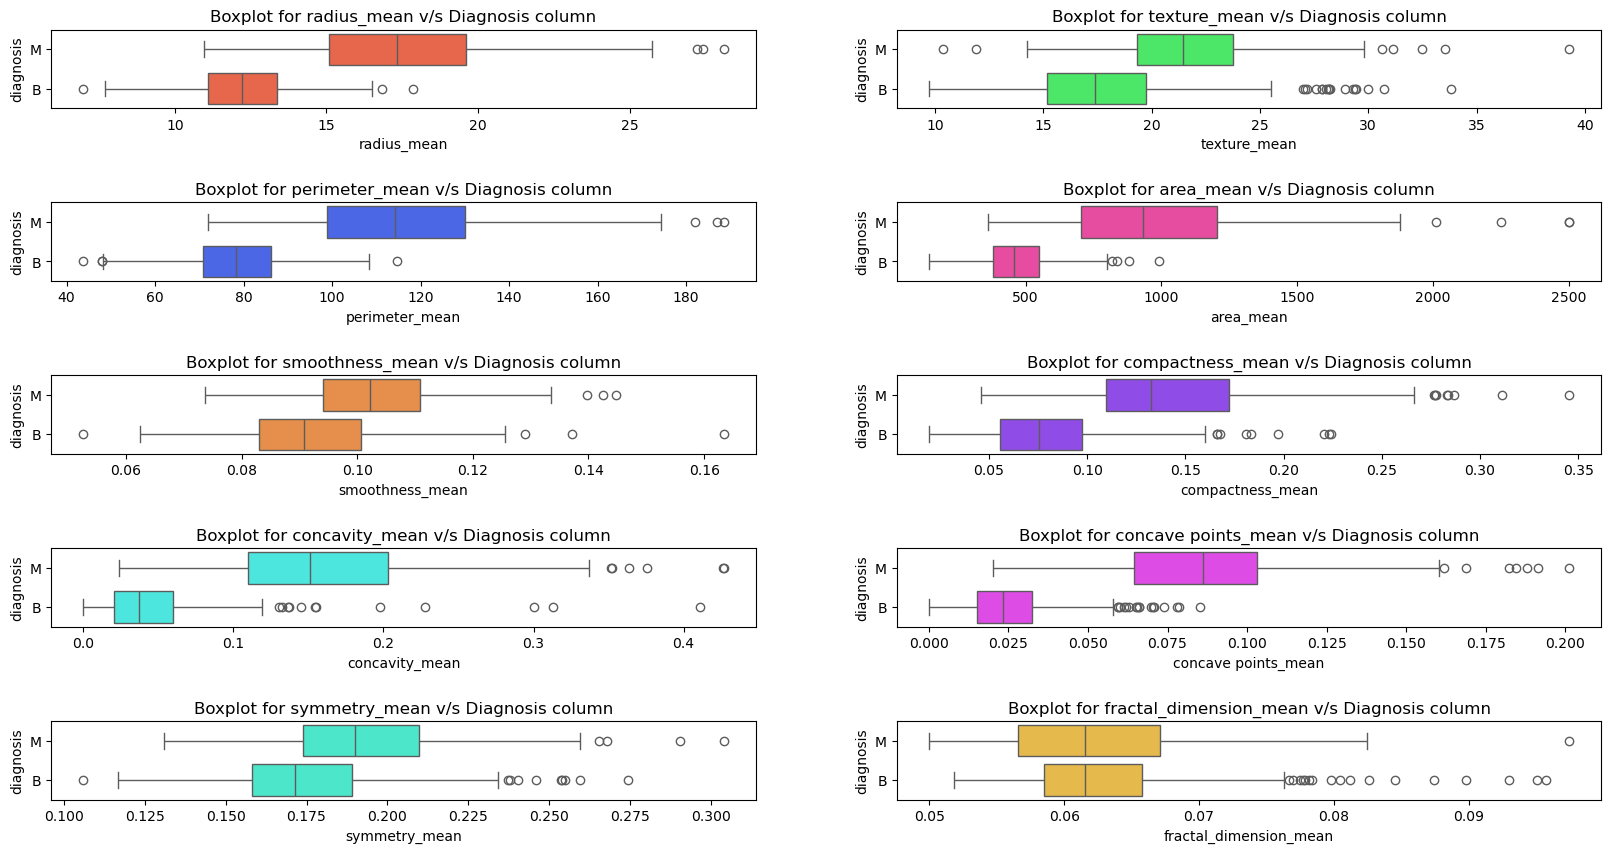

In [22]:
# Box plots for Num v/s Cat(Target) for mean data

fig, axes = plt.subplots(5,2, figsize=(20,10))
plt.subplots_adjust(hspace = 1.2)
axes = axes.flatten()

features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave points_mean",
    "symmetry_mean",
    "fractal_dimension_mean"
]



colors = [
    "#FF5733",  # red
    "#33FF57",  # green
    "#3357FF",  # blue
    "#FF33A1",  # pink
    "#FF8C33",  # orange
    "#8C33FF",  # purple
    "#33FFF5",  # turquoise
    "#F533FF",  # magenta
    "#33FFDB",  # cyan
    "#FFC433"   # yellow
]


for ax, feature, color in zip(axes,features,colors):
    sns.boxplot(data = data, x = data[feature], y = data['diagnosis'], ax = ax, color = color)
    ax.set_title(f'Boxplot for {feature} v/s Diagnosis column')
plt.show()

# Observation 5

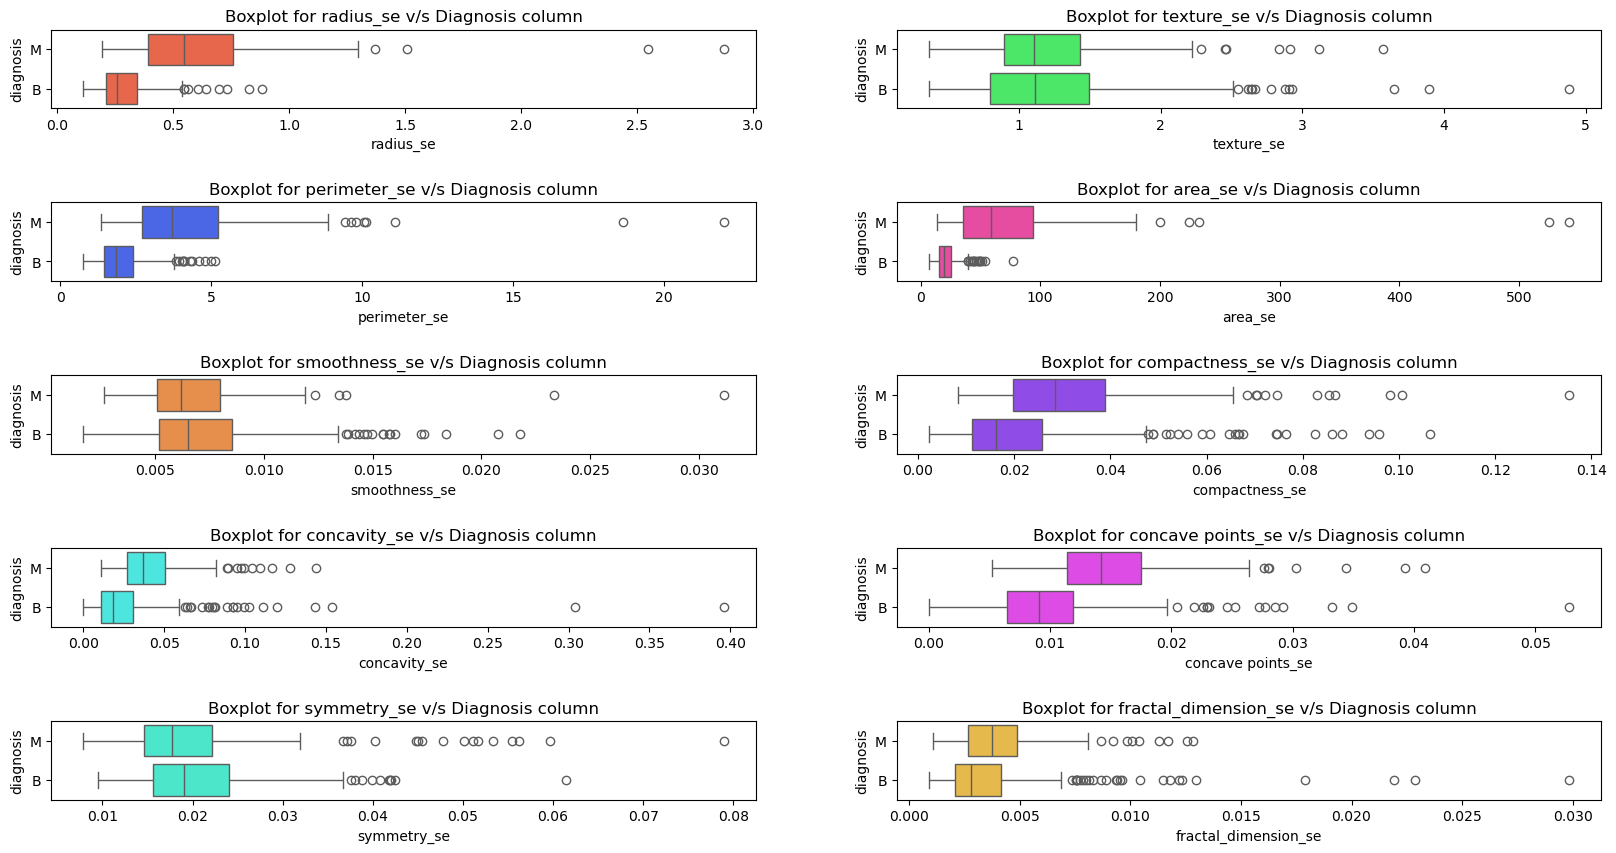

In [23]:
# Box plots for Num v/s Cat(Target) for SE columns

fig, axes = plt.subplots(5,2, figsize=(20,10))
plt.subplots_adjust(hspace = 1.2)
axes = axes.flatten()

features = [
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave points_se",
    "symmetry_se",
    "fractal_dimension_se"
]



colors = [
    "#FF5733",  # red
    "#33FF57",  # green
    "#3357FF",  # blue
    "#FF33A1",  # pink
    "#FF8C33",  # orange
    "#8C33FF",  # purple
    "#33FFF5",  # turquoise
    "#F533FF",  # magenta
    "#33FFDB",  # cyan
    "#FFC433"   # yellow
]


for ax, feature, color in zip(axes,features,colors):
    sns.boxplot(data = data, x = data[feature], y = data['diagnosis'], ax = ax, color = color)
    ax.set_title(f'Boxplot for {feature} v/s Diagnosis column')
plt.show()

# Observation 6

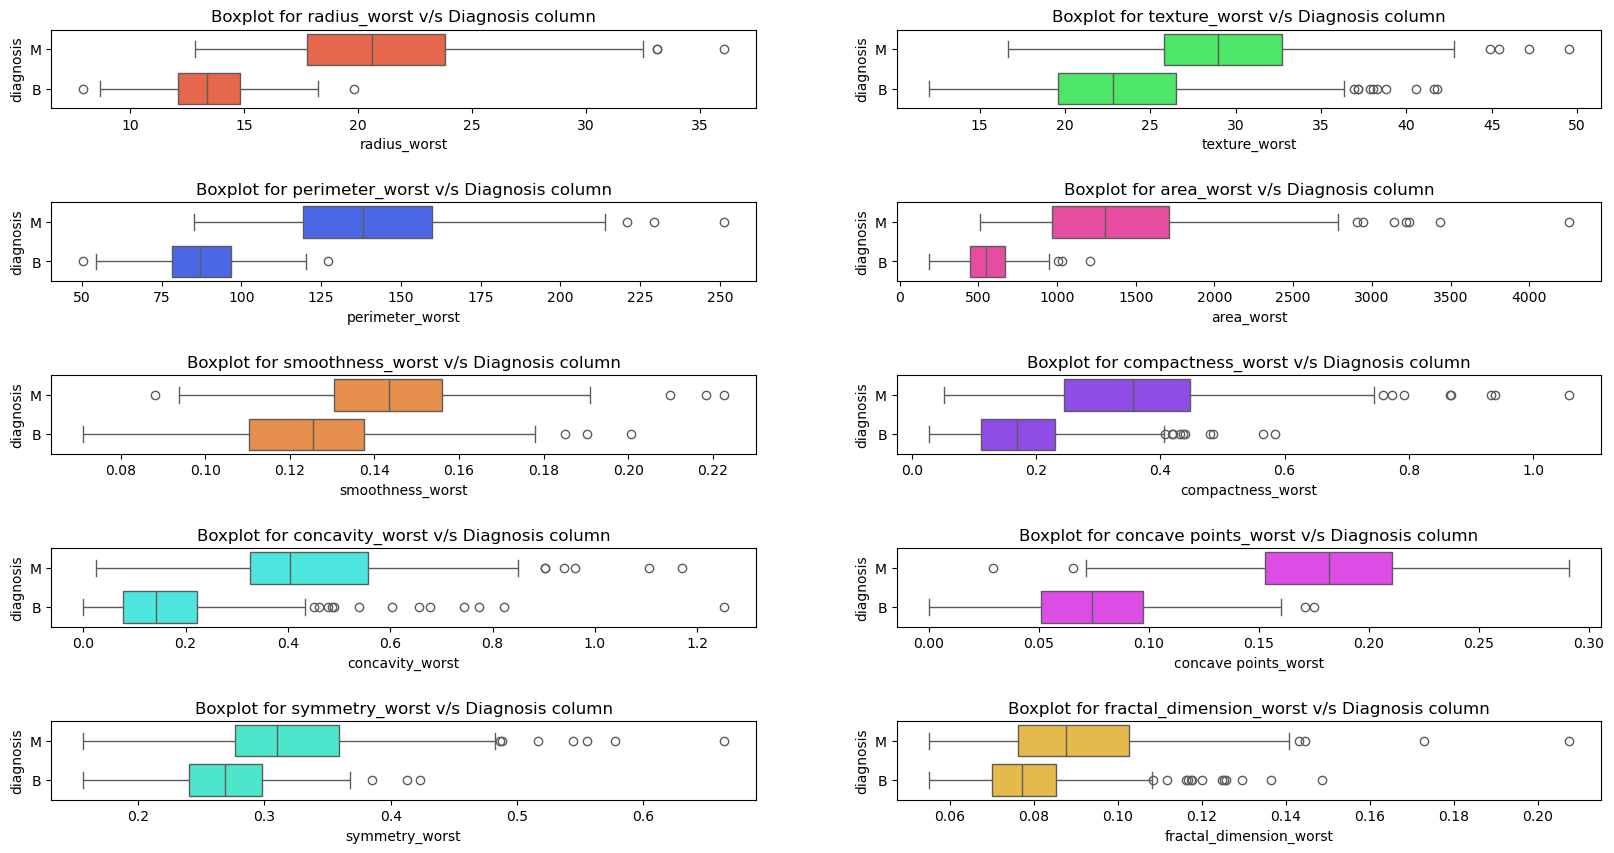

In [24]:
# Box plots for Num v/s Cat(Target) for worst columns

fig, axes = plt.subplots(5,2, figsize=(20,10))
plt.subplots_adjust(hspace = 1.2)
axes = axes.flatten()


features = [
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]


colors = [
    "#FF5733",  # red
    "#33FF57",  # green
    "#3357FF",  # blue
    "#FF33A1",  # pink
    "#FF8C33",  # orange
    "#8C33FF",  # purple
    "#33FFF5",  # turquoise
    "#F533FF",  # magenta
    "#33FFDB",  # cyan
    "#FFC433"   # yellow
]


for ax, feature, color in zip(axes,features,colors):
    sns.boxplot(data = data, x = data[feature], y = data['diagnosis'], ax = ax, color = color)
    ax.set_title(f'Boxplot for {feature} v/s Diagnosis column')
plt.show()

### Colinearity(Num v/s Num)

In [ ]:
corr = data['radius_mean'].corr(data['concavity_mean'])
print(f' The correlation between radius_mean & concavity_mean is {round(corr, 2)}')

In [ ]:
data.corr(numeric_only = True)

In [ ]:
# Select only mean columns
mean_cols = [col for col in data.columns if "_mean" in col]

# Correlation matrix for mean features
corr_mean = data[mean_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_mean,
    cmap="coolwarm",
    annot=True,        # correlation values
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={'shrink': 0.8},
    mask = np.triu(corr_mean)
)
plt.title("Correlation Heatmap: Mean Features", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Select only se columns
se_cols = [col for col in data.columns if "_se" in col]

# Correlation matrix for mean features
corr_se = data[se_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_se,
    cmap="coolwarm",
    annot=True,        # correlation values
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={'shrink': 0.8},
    mask = np.triu(corr_mean)
)
plt.title("Correlation Heatmap: SE Features", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Select only se columns
worst_cols = [col for col in data.columns if "_worst" in col]

# Correlation matrix for mean features
corr_worst = data[worst_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_worst,
    cmap="coolwarm",
    annot=True,        # correlation values
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={'shrink': 0.8},
    mask = np.triu(corr_mean)
)
plt.title("Correlation Heatmap: Worst Features", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Multivariate Analysis

In [ ]:
# What happens to radius_mean against all other numerical variable of mean columns

# Subplots: 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.flatten()

# Adjust spacing
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# Target variable
y_var = "radius_mean"

# Other mean columns to compare against
x_vars = [
    "texture_mean", "perimeter_mean", "area_mean", 
    "smoothness_mean", "compactness_mean", "concavity_mean", 
    "concave points_mean", "symmetry_mean", "fractal_dimension_mean"
]

# Plot each scatterplot with regression line
for ax, x in zip(axes, x_vars):
    sns.scatterplot(data=data, x=x, y=y_var, hue="diagnosis", palette={"M": "red", "B": "green"}, ax=ax, alpha=0.6)
    sns.regplot(data=data, x=x, y=y_var, scatter=False, ax=ax, line_kws={'color':'black'})
    ax.set_title(f"{y_var} vs {x}", fontsize=12)

plt.show()

In [ ]:
# What happens to radius_se against all other numerical variable of SE columns

# Subplots: 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.flatten()

# Adjust spacing
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# Target variable
y_var = "radius_mean"

# Other SE columns to compare against
x_vars = [
    "texture_se", "perimeter_se", "area_se", 
    "smoothness_se", "compactness_se", "concavity_se", 
    "concave points_se", "symmetry_se", "fractal_dimension_se"
]

# Plot each scatterplot with regression line
for ax, x in zip(axes, x_vars):
    sns.scatterplot(data=data, x=x, y=y_var, hue="diagnosis", palette={"M": "red", "B": "green"}, ax=ax, alpha=0.6)
    sns.regplot(data=data, x=x, y=y_var, scatter=False, ax=ax, line_kws={'color':'black'})
    ax.set_title(f"{y_var} vs {x}", fontsize=12)

plt.show()

In [ ]:
# What happens to radius_worst against all other numerical variable of worst columns

# Subplots: 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.flatten()

# Adjust spacing
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# Target variable
y_var = "radius_mean"

# Other worst columns to compare against
x_vars = [
    "texture_worst", "perimeter_worst", "area_worst", 
    "smoothness_worst", "compactness_worst", "concavity_worst", 
    "concave points_worst", "symmetry_worst", "fractal_dimension_worst"
]

# Plot each scatterplot with regression line
for ax, x in zip(axes, x_vars):
    sns.scatterplot(data=data, x=x, y=y_var, hue="diagnosis", palette={"M": "red", "B": "green"}, ax=ax, alpha=0.6)
    sns.regplot(data=data, x=x, y=y_var, scatter=False, ax=ax, line_kws={'color':'black'})
    ax.set_title(f"{y_var} vs {x}", fontsize=12)

plt.show()

In [ ]:
data.describe(percentiles=[0, 0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99])